<a href="https://colab.research.google.com/github/ceanmt/-kivic-Portafolio-PHP/blob/main/Proyecto%20mathematics%20Especiales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:63: SyntaxWarning: invalid escape sequence '\s'
<>:63: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6531/511767663.py:63: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Serie de Taylor (Maclaurin) para $\sin(x)$")


Librerías cargadas exitosamente.

SECCIÓN 1: Transformada de Laplace con SymPy
Función original f(t): exp(-a*t)
Transformada F(s):     1/(a + s)
Condición de convergencia: -a
----------------------------------------------------------------------

SECCIÓN 2: Aproximación Numérica mediante Series de Taylor
Error máximo de la aproximación con 3 términos: 0.5240


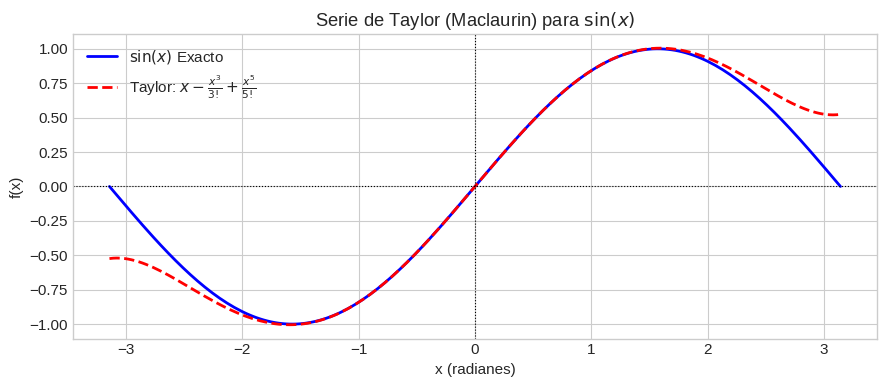

----------------------------------------------------------------------

SECCIÓN 3: Serie de Fourier para f(t) = t
Serie de Fourier truncada a 3 armónicos:
                      2⋅sin(3⋅t)
2⋅sin(t) - sin(2⋅t) + ──────────
                          3     


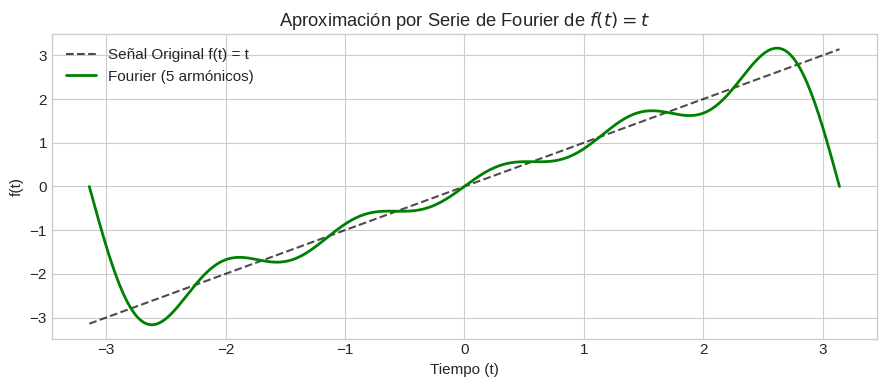

----------------------------------------------------------------------

SECCIÓN 4: Transformada Rápida de Fourier (FFT) y Filtrado Pasa-Bajos


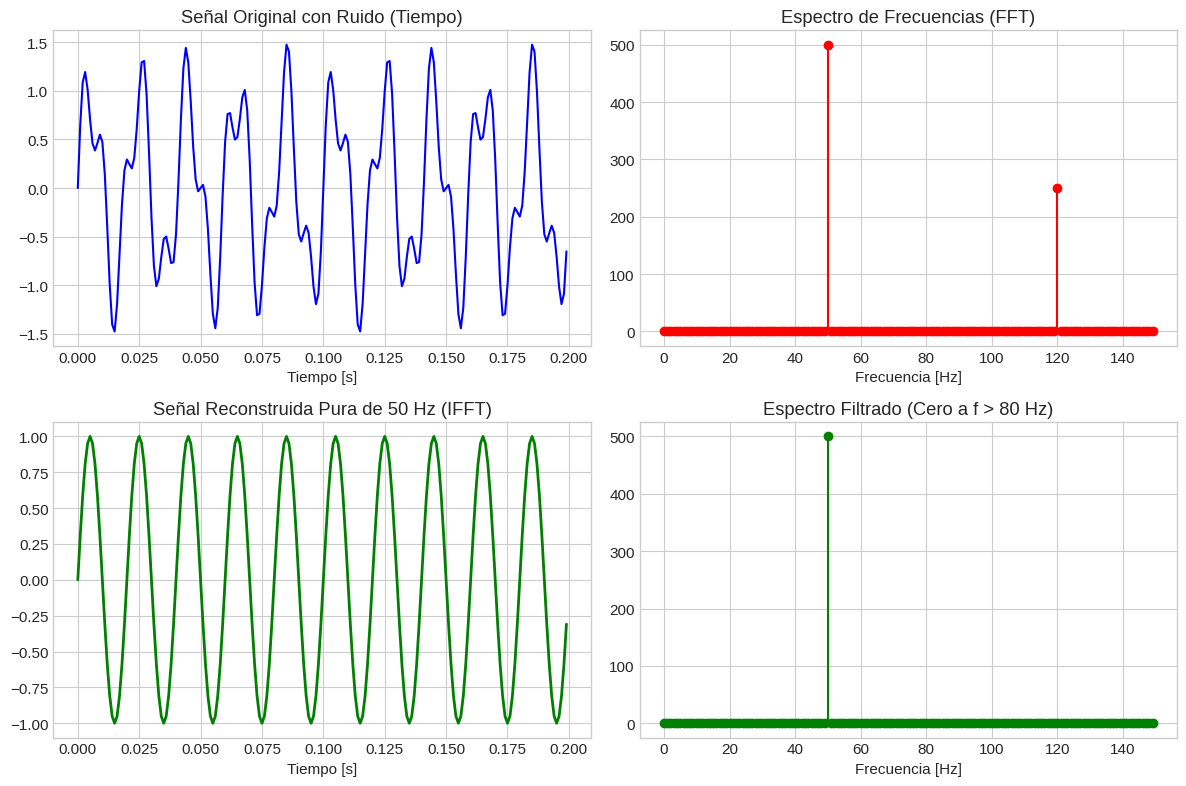

----------------------------------------------------------------------

SECCIÓN 5: Análisis de Polos en el Dominio Z y Simulación Recursiva
Polos calculados por SciPy: [1.1]
¿El sistema es estable?:    False
Valor final sistema Estable   (n=20): 0.0144
Valor final sistema Inestable (n=20): 31.95


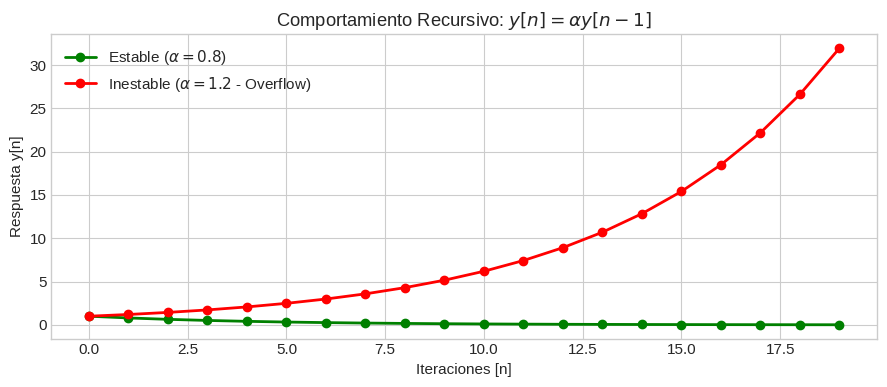

----------------------------------------------------------------------

SECCIÓN 6: Solución Computacional de los Retos Propuestos

RETO 1: Laplace y Taylor
1. L{t * e^(-2t) * sin(3t)} =  I/(2*(s + 2 + 3*I)**2) - I/(2*(s + 2 - 3*I)**2)
2. Serie de Maclaurin (4 términos) de e^(-x)*cos(x): 1 - x + x**3/3 + O(x**4)

RETO 2: Filtro Pasa-Altos con FFT


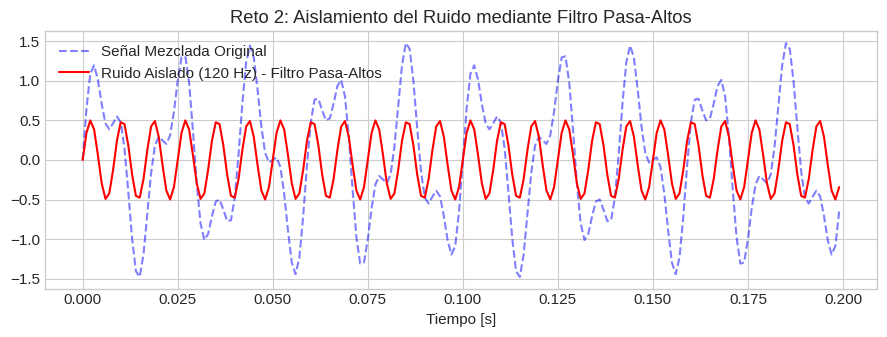


RETO 3: Estabilidad de Ecuación en Diferencias de 2do Orden
Polos del sistema: [0.75+0.37080992j 0.75-0.37080992j]
Magnitud de los polos: [0.83666003 0.83666003]
¿El algoritmo es estable?: True


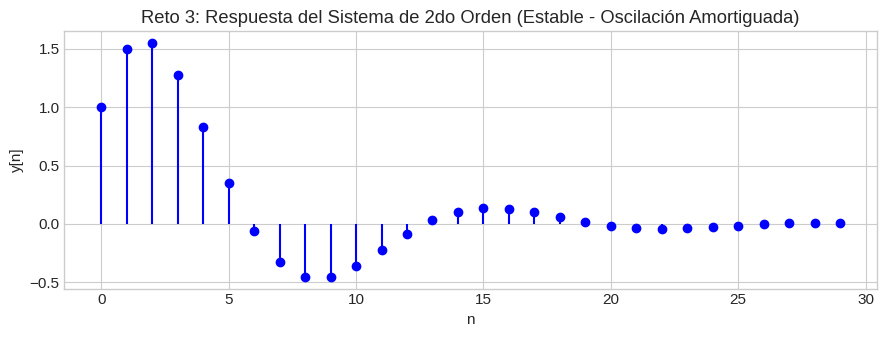


Ejecución del script completada.


In [1]:
# ------------------------------------------------------------------------------
# 0. IMPORTACIÓN DE LIBRERÍAS
# ------------------------------------------------------------------------------
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import math
from scipy.fft import fft, ifft, fftfreq
from scipy import signal

# Configuración estética global para los gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("Librerías cargadas exitosamente.\n")


# ==============================================================================
# SECCIÓN 1: LAPLACE SIMBÓLICO (SymPy)
# ==============================================================================
print("=" * 70)
print("SECCIÓN 1: Transformada de Laplace con SymPy")
print("=" * 70)

# 1. Definir símbolos matemáticos
t, s = sp.symbols('t s')
a = sp.symbols('a', real=True, positive=True)

# 2. Definir la función f(t) = exp(-a*t)
f = sp.exp(-a * t)

# 3. Calcular la Transformada de Laplace
F, cond, _ = sp.laplace_transform(f, t, s)

print("Función original f(t):", f)
print("Transformada F(s):    ", F)
print("Condición de convergencia:", cond)
print("-" * 70 + "\n")


# ==============================================================================
# SECCIÓN 2: SERIES DE TAYLOR (Seno)
# ==============================================================================
print("=" * 70)
print("SECCIÓN 2: Aproximación Numérica mediante Series de Taylor")
print("=" * 70)

# Rango de evaluación de -pi a pi
x_vals = np.linspace(-np.pi, np.pi, 200)

# Cálculo exacto vs Serie de Taylor truncada (3 términos)
y_exact = np.sin(x_vals)
y_taylor = x_vals - (x_vals**3)/math.factorial(3) + (x_vals**5)/math.factorial(5)

error_max = np.max(np.abs(y_exact - y_taylor))
print(f"Error máximo de la aproximación con 3 términos: {error_max:.4f}")

# Gráfica de Taylor vs Exacto
plt.figure(figsize=(9, 4))
plt.plot(x_vals, y_exact, 'b-', label=r'$\sin(x)$ Exacto', linewidth=2)
plt.plot(x_vals, y_taylor, 'r--', label=r'Taylor: $x - \frac{x^3}{3!} + \frac{x^5}{5!}$', linewidth=2)
plt.title("Serie de Taylor (Maclaurin) para $\sin(x)$")
plt.xlabel("x (radianes)")
plt.ylabel("f(x)")
plt.axhline(0, color='black', linewidth=0.8, linestyle=':')
plt.axvline(0, color='black', linewidth=0.8, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()
print("-" * 70 + "\n")


# ==============================================================================
# SECCIÓN 3: SERIES DE FOURIER SIMBÓLICAS (SymPy)
# ==============================================================================
print("=" * 70)
print("SECCIÓN 3: Serie de Fourier para f(t) = t")
print("=" * 70)

t_sym = sp.symbols('t')
f_fourier = t_sym

# Cálculo de la serie de Fourier en [-pi, pi]
serie = sp.fourier_series(f_fourier, (t_sym, -sp.pi, sp.pi))
serie_truncada = serie.truncate(3)

print("Serie de Fourier truncada a 3 armónicos:")
sp.pprint(serie_truncada)

# Visualización de la aproximación de Fourier
f_num = sp.lambdify(t_sym, serie.truncate(5), 'numpy')
t_grid = np.linspace(-np.pi, np.pi, 400)

plt.figure(figsize=(9, 4))
plt.plot(t_grid, t_grid, 'k--', label='Señal Original f(t) = t', alpha=0.7)
plt.plot(t_grid, f_num(t_grid), 'g-', label='Fourier (5 armónicos)', linewidth=2)
plt.title("Aproximación por Serie de Fourier de $f(t) = t$")
plt.xlabel("Tiempo (t)")
plt.ylabel("f(t)")
plt.legend()
plt.tight_layout()
plt.show()
print("-" * 70 + "\n")


# ==============================================================================
# SECCIÓN 4: ANÁLISIS DE FRECUENCIAS (FFT, FILTRADO E IFFT)
# ==============================================================================
print("=" * 70)
print("SECCIÓN 4: Transformada Rápida de Fourier (FFT) y Filtrado Pasa-Bajos")
print("=" * 70)

# 1. Creación de la señal de prueba
fs = 1000  # Frecuencia de muestreo (1000 Hz)
t_signal = np.arange(0, 1.0, 1.0/fs)
# Señal = 50 Hz (útil) + 120 Hz (ruido/armónico)
x_signal = np.sin(2 * np.pi * 50 * t_signal) + 0.5 * np.sin(2 * np.pi * 120 * t_signal)

# 2. FFT
N = len(x_signal)
X_freq = fft(x_signal)
frecuencias = fftfreq(N, 1/fs)

magnitud = np.abs(X_freq)[:N//2]
frecuencias_pos = frecuencias[:N//2]

# 3. Filtrado Pasa-Bajos (Eliminar f > 80 Hz)
X_filtrado = X_freq.copy()
indices_ruido = np.abs(frecuencias) > 80
X_filtrado[indices_ruido] = 0

# 4. Reconstrucción con IFFT
x_limpia = np.real(ifft(X_filtrado))

# Gráficas
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Subplot 1: Señal original en tiempo
axs[0, 0].plot(t_signal[:200], x_signal[:200], 'b')
axs[0, 0].set_title("Señal Original con Ruido (Tiempo)")
axs[0, 0].set_xlabel("Tiempo [s]")

# Subplot 2: Espectro de Frecuencia (FFT)
axs[0, 1].stem(frecuencias_pos[:150], magnitud[:150], linefmt='r-', markerfmt='ro', basefmt=" ")
axs[0, 1].set_title("Espectro de Frecuencias (FFT)")
axs[0, 1].set_xlabel("Frecuencia [Hz]")

# Subplot 3: Espectro Filtrado
axs[1, 1].stem(frecuencias_pos[:150], np.abs(X_filtrado)[:150], linefmt='g-', markerfmt='go', basefmt=" ")
axs[1, 1].set_title("Espectro Filtrado (Cero a f > 80 Hz)")
axs[1, 1].set_xlabel("Frecuencia [Hz]")

# Subplot 4: Señal reconstruida (IFFT)
axs[1, 0].plot(t_signal[:200], x_limpia[:200], 'g', linewidth=2)
axs[1, 0].set_title("Señal Reconstruida Pura de 50 Hz (IFFT)")
axs[1, 0].set_xlabel("Tiempo [s]")

plt.tight_layout()
plt.show()
print("-" * 70 + "\n")


# ==============================================================================
# SECCIÓN 5: TRANSFORMADA Z Y ESTABILIDAD RECURSIVA
# ==============================================================================
print("=" * 70)
print("SECCIÓN 5: Análisis de Polos en el Dominio Z y Simulación Recursiva")
print("=" * 70)

# H(z) = z / (z - 1.1) -> Inestable porque polo = 1.1 > 1
num = [1, 0]
den = [1, -1.1]

ceros, polos, ganancia = signal.tf2zpk(num, den)
print(f"Polos calculados por SciPy: {polos}")
print(f"¿El sistema es estable?:    {np.all(np.abs(polos) < 1)}")

# Simulación de la respuesta en el tiempo
iteraciones = 20
y_estable = np.zeros(iteraciones)
y_inestable = np.zeros(iteraciones)

y_estable[0] = 1.0
y_inestable[0] = 1.0

for n in range(1, iteraciones):
    y_estable[n] = 0.8 * y_estable[n-1]     # alpha = 0.8 (Polo en 0.8 < 1)
    y_inestable[n] = 1.2 * y_inestable[n-1]   # alpha = 1.2 (Polo en 1.2 > 1)

print(f"Valor final sistema Estable   (n=20): {y_estable[-1]:.4f}")
print(f"Valor final sistema Inestable (n=20): {y_inestable[-1]:.2f}")

plt.figure(figsize=(9, 4))
plt.plot(y_estable, 'go-', label=r'Estable ($\alpha = 0.8$)', linewidth=2)
plt.plot(y_inestable, 'ro-', label=r'Inestable ($\alpha = 1.2$ - Overflow)', linewidth=2)
plt.title("Comportamiento Recursivo: $y[n] = \\alpha y[n-1]$")
plt.xlabel("Iteraciones [n]")
plt.ylabel("Respuesta y[n]")
plt.legend()
plt.tight_layout()
plt.show()
print("-" * 70 + "\n")


# ==============================================================================
# SECCIÓN 6: SOLUCIÓN A LOS RETOS PROPUESTOS
# ==============================================================================
print("=" * 70)
print("SECCIÓN 6: Solución Computacional de los Retos Propuestos")
print("=" * 70)

# --- RETO 1 ---
print("\nRETO 1: Laplace y Taylor")
t_r1, x_r1, s_r1 = sp.symbols('t x s')
f_r1 = t_r1 * sp.exp(-2*t_r1) * sp.sin(3*t_r1)
F_r1, _, _ = sp.laplace_transform(f_r1, t_r1, s_r1)

g_r1 = sp.exp(-x_r1) * sp.cos(x_r1)
taylor_g = sp.series(g_r1, x_r1, 0, 4)

print("1. L{t * e^(-2t) * sin(3t)} = ", F_r1)
print("2. Serie de Maclaurin (4 términos) de e^(-x)*cos(x):", taylor_g)


# --- RETO 2 ---
print("\nRETO 2: Filtro Pasa-Altos con FFT")
X_pasa_altos = X_freq.copy()
# Eliminar frecuencias menores a 80 Hz para conservar el ruido
X_pasa_altos[np.abs(frecuencias) < 80] = 0
x_ruido_aislado = np.real(ifft(X_pasa_altos))

plt.figure(figsize=(9, 3.5))
plt.plot(t_signal[:200], x_signal[:200], 'b--', alpha=0.5, label='Señal Mezclada Original')
plt.plot(t_signal[:200], x_ruido_aislado[:200], 'r', label='Ruido Aislado (120 Hz) - Filtro Pasa-Altos')
plt.title("Reto 2: Aislamiento del Ruido mediante Filtro Pasa-Altos")
plt.xlabel("Tiempo [s]")
plt.legend()
plt.tight_layout()
plt.show()


# --- RETO 3 ---
print("\nRETO 3: Estabilidad de Ecuación en Diferencias de 2do Orden")
# y[n] - 1.5 y[n-1] + 0.7 y[n-2] = x[n]
num_r3 = [1, 0, 0]
den_r3 = [1, -1.5, 0.7]

ceros_r3, polos_r3, _ = signal.tf2zpk(num_r3, den_r3)
magnitud_polos = np.abs(polos_r3)
es_estable_r3 = np.all(magnitud_polos < 1)

print(f"Polos del sistema: {polos_r3}")
print(f"Magnitud de los polos: {magnitud_polos}")
print(f"¿El algoritmo es estable?: {es_estable_r3}")

# Simulación recursiva manual
N_iter = 30
y_r3 = np.zeros(N_iter)
y_r3[0] = 1.0
y_r3[1] = 1.5

for n in range(2, N_iter):
    y_r3[n] = 1.5 * y_r3[n-1] - 0.7 * y_r3[n-2]

plt.figure(figsize=(9, 3.5))
plt.stem(range(N_iter), y_r3, linefmt='b-', markerfmt='bo', basefmt=" ")
plt.title("Reto 3: Respuesta del Sistema de 2do Orden (Estable - Oscilación Amortiguada)")
plt.xlabel("n")
plt.ylabel("y[n]")
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("Ejecución del script completada.")
print("=" * 70)